# Context

In this notebook we will do some data imputation and creation of new potential valuable columns

# Load packages

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import mode

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.impute import SimpleImputer


# from scipy.stats import chi2_contingency
import warnings

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

# Load data

using relative paths

In [2]:
filename = "FE_regression.ipynb"  # Current file name
print(f"Current file name: {filename}\n")
print(f"Current absolute path: {os.getcwd()}\n")

# Specify the paths, relative to the current file
ACTUAL_DIR = os.path.dirname(os.path.abspath(filename))
BASE_DIR = os.path.dirname(ACTUAL_DIR)
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(DATA_DIR, "output_data")

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

Current file name: FE_regression.ipynb

Current absolute path: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\Aprendizaje automatico 1\PROYECTO FINAL\ML1_industria_azucarera\notebooks

BASE_DIR: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\Aprendizaje automatico 1\PROYECTO FINAL\ML1_industria_azucarera
DATA_DIR: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\Aprendizaje automatico 1\PROYECTO FINAL\ML1_industria_azucarera\data
OUTPUT_DIR: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\Aprendizaje automatico 1\PROYECTO FINAL\ML1_industria_azucarera\data\output_data


In [3]:
df_base = pd.read_csv(os.path.join(OUTPUT_DIR, "suertes_clean.csv")).iloc[:, 1:]

df_base.head(5)

,tch,pct_sac_caña,periodo,hacienda,zona,suerte,suelo,area_neta,dist_km,cerca_de,variedad,cult_organico,num_cosechas,f_siembra,f_ult_corte,edad_ult_cos,edad_precosecha,vejez,pct_infest_diatrea,fec_madur_,producto,dosis_madurante,semanas_mad_,ult_riego,ddult_riego,num_riegos,m3_riego,lluvias_2_meses_ant_,lluvias_0__3,lluvias_tres_a_seis,lluvias_seis_a_nueve,lluvias_9_a_cos,lluvias_ciclo,tipo_quema,t_corte,codigo_estacion,temp__media_0_3,temp__media_ciclo,temp_max_ciclo,temp_min_ciclo,humedad_rel_media_0_3,humedad_rel_media_ciclo,oscilacion_temp_med_0_3,oscilacion_temp_ciclo,radicion_solar_0_3,radiacion_solar_ciclo,precipitacion_0_3,precipitacion_ciclo,evaporacion_0_3,evaporacion_ciclo,vinaza,fosfato_jugo,urea_46pct_,mez,boro_granul_,microzinc,nito_xtend,sul_amonio,nitrax_s
0,149.714285,9.9300,201701,80108,ip06,324A,manuelita,1.26,7.5,el_cerrito,cc01_1940,0.0,1,2015-04-01,2017-01-20,12.68,11.27,NaN,NaN,NaN,no_especificado,NaN,NaN,2016-08-25,148.0,1.0,2588.40,192.0,110.0,369.0,103.0,403.0,985.0,verde,manual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13860.0,298.0000,200.0,50.0,NaN,NaN,NaN,NaN,NaN
1,129.673316,10.7856,201701,80108,ip06,326,manuelita,4.01,7.5,el_cerrito,cc85_92,0.0,8,2007-07-09,2017-01-21,12.02,10.58,15.540,NaN,NaN,no_especificado,NaN,NaN,2016-10-10,103.0,3.0,19960.50,192.0,190.0,309.0,168.0,314.0,981.0,q_programada,manual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36090.0,174.6750,600.0,200.0,80.0,80.0,NaN,NaN,NaN
2,139.855072,11.5614,201701,80108,ip06,328A,manuelita,2.07,7.5,el_cerrito,cc04_667,0.0,1,2015-02-18,2017-01-28,12.48,10.81,1.930,NaN,2016-12-13,bonus_250_ec_regulador_fisiologico,1.0,6.571428,2016-09-17,133.0,2.0,4933.08,172.0,180.0,307.0,149.0,345.0,981.0,verde,mecanizado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,294.1528,200.0,100.0,NaN,NaN,NaN,NaN,NaN
3,157.754901,10.9520,201701,80108,ip06,331B,genova,3.06,7.5,el_cerrito,rb73_2223,0.0,3,2013-07-31,2017-01-20,12.09,10.68,10.312,NaN,2016-12-13,bonus_250_ec_regulador_fisiologico,1.0,5.428571,2016-09-28,114.0,4.0,33390.86,298.0,348.0,345.0,182.0,476.0,1351.0,verde,manual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36720.0,286.0000,450.0,150.0,NaN,NaN,NaN,NaN,NaN
4,127.289256,9.3950,201701,80108,ip06,332B,genova,1.21,7.5,el_cerrito,cc97_7170,0.0,1,2015-02-01,2017-01-20,12.12,10.71,NaN,NaN,NaN,no_especificado,NaN,NaN,NaN,NaN,NaN,NaN,149.0,280.0,308.0,152.0,298.0,1038.0,verde,manual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,257.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
pd.DataFrame(
    {
        "column_format": df_base.dtypes.apply(lambda x: x.name).tolist(),
        "num_unique_values": df_base.nunique().tolist(),
        "num_nan_values": df_base.isna().sum().tolist(),
        "pct_nan": [
            round((df_base[col].isna().sum().tolist() / df_base.shape[0]) * 100, 1)
            for col in df_base.columns
        ],
    },
    index=df_base.columns,
).sort_values(by="num_nan_values")

,column_format,num_unique_values,num_nan_values,pct_nan
tch,float64,20606,0,0.0
periodo,int64,90,0,0.0
hacienda,int64,926,0,0.0
zona,object,6,0,0.0
area_neta,float64,2390,0,0.0
suerte,object,1204,0,0.0
f_ult_corte,object,2555,0,0.0
variedad,object,57,0,0.0
edad_ult_cos,float64,493,0,0.0
num_cosechas,int64,32,0,0.0


We can see group of columns with the same number of NaN values

# Imputation of columns

Next, we will perform an imputation of variables, by groups of variables.  
We will take into account criteria according to the context of sugar cane crops in order to carry out the imputations with the required rigor.

In [5]:
# Crear copia del dataframe para trabajar
df_imp = df_base.copy()

## **Grupo 0: Suelo y dist_km**

Estrategia:

- Suelo (categórica): imputar por hacienda-variedad.
- Imputación de 'dist_km' por hacienda: Las suertes de una misma hacienda suelen estar en una misma zona geográfica, por ende sus distancias al punto de entrega son similares.

In [6]:
# Imputación de suelo por hacienda-variedad
df_imp["suelo"] = df_imp.groupby(["hacienda", "variedad"])["suelo"].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
)

# Imputación de 'dist_km' por hacienda
df_imp["dist_km"] = df_imp.groupby("hacienda")["dist_km"].transform(
    lambda x: x.fillna(x.mode())
)

## **GRUPO 1: Fertilizantes / productos aplicados (nulos > 80%)**
- urea_46pct_, mez, microzinc, boro_granul_, nito_xtend, sul_amonio, nitrax_s, vinaza

Estrategia aplicada:
- Dividimos todos los valores de fertilizante por las hectareas del cultivo para que sean mas comparables.
- Se imputa teniendo en cuenta periodos igual o menores a cada cosecha y usando el promedio de cultivos con valores iguales de hacienda-variedad-suelo.


In [7]:
# Lista de columnas de fertilizantes/productos
fertilizer_cols = [
    "urea_46pct_",
    "mez",
    "microzinc",
    "boro_granul_",
    "nito_xtend",
    "sul_amonio",
    "nitrax_s",
    "vinaza",
]

In [8]:
df_imp[fertilizer_cols].isna().sum()

urea_46pct_     19990
mez             19773
microzinc       19584
boro_granul_    19467
nito_xtend      17161
sul_amonio      19385
nitrax_s        19961
vinaza          16743
dtype: int64

In [9]:
# Dividir todas las columnas de fertilizantes por el tamaño del cultivo (hectareas)
df_imp[fertilizer_cols] = df_imp[fertilizer_cols].div(df_imp.area_neta, axis=0)

In [10]:
# Imputación sujeta a el periodo y cosechas similares

for col in fertilizer_cols:
    ## Para cada fila, calcula la media de TODOS los valores de periodos anteriores en su grupo (hacienda, variedad, suelo)

    # Ya contamos con el conjunto de datos ordenado por periodo (cronologicamente)

    # Imputación solo con datos históricos y por grupo (hacienda, variedad, suelo)
    temp_col = df_imp.groupby(["hacienda", "variedad", "suelo"])[col].transform(
        lambda x: x.expanding().mean()  # Media acumulativa de períodos iguales o anteriores
    )
    df_imp[col] = np.where(df_imp[col].isna(), temp_col, df_imp[col])

In [11]:
df_imp[fertilizer_cols].isna().sum()

urea_46pct_     17295
mez             17575
microzinc       17611
boro_granul_    17552
nito_xtend      15771
sul_amonio      18019
nitrax_s        18549
vinaza          14929
dtype: int64

## **GRUPO 2: Variables climáticas (~78% nulos)**

temp__media_0_3, precipitacion_0_3, evaporacion_ciclo, etc. 

Estrategia a usar:
- Construir una nueva variable categorica teniendo en cuenta la edad de los cultivos (rango de edad del cultivo, cada 2 meses)
- Imputar con el promedio de cosechas similares agrupadas por periodo, zona, cerca_de y rango_edad_ult_cos.  
De esta manera, utilizamos cosechas cercanas geograficamente y con la misma edad para imputar los valores de las variables climáticas.


In [12]:
# 1. Calcular el mínimo redondeado hacia abajo
min_edad = np.floor(df_imp["edad_ult_cos"].min())

# 2. Calcular el percentil 99 y redondear hacia arriba
p99 = np.percentile(df_imp["edad_ult_cos"].dropna(), 99)
max_edad = np.ceil(p99)

# 3. Crear bins de 2 en 2 desde el mínimo hasta el percentil 99
bins = list(np.arange(min_edad, max_edad, 2))
bins.append(np.inf)  # Para capturar valores mayores al percentil 99

# 4. Crear etiquetas para los rangos
labels = [f"{int(bins[i])}-{int(bins[i+1]-1)} meses" for i in range(len(bins) - 2)]
labels.append(f">= {int(max_edad)} meses")  # Última categoría para outliers

# 5. Categorizar la columna
df_imp["rango_edad_ult_cos"] = pd.cut(
    df_imp["edad_ult_cos"], bins=bins, labels=labels, right=False
)

In [13]:
climate_cols = [
    "oscilacion_temp_ciclo",
    "temp__media_0_3",
    "temp__media_ciclo",
    "temp_max_ciclo",
    "temp_min_ciclo",
    "humedad_rel_media_0_3",
    "humedad_rel_media_ciclo",
    "oscilacion_temp_med_0_3",
    "radicion_solar_0_3",
    "radiacion_solar_ciclo",
    "precipitacion_0_3",
    "precipitacion_ciclo",
    "evaporacion_0_3",
    "evaporacion_ciclo",
]

In [14]:
df_imp[climate_cols].isna().sum()

oscilacion_temp_ciclo      16278
temp__media_0_3            16278
temp__media_ciclo          16278
temp_max_ciclo             16278
temp_min_ciclo             16278
humedad_rel_media_0_3      16278
humedad_rel_media_ciclo    16278
oscilacion_temp_med_0_3    16278
radicion_solar_0_3         16278
radiacion_solar_ciclo      16278
precipitacion_0_3          16278
precipitacion_ciclo        16278
evaporacion_0_3            16278
evaporacion_ciclo          16278
dtype: int64

In [15]:
# Imputación con el promedio por grupo de cultivos comparables
for col in climate_cols:
    df_imp[col] = df_imp.groupby(["periodo", "zona", "cerca_de", "rango_edad_ult_cos"])[
        col
    ].transform(lambda x: x.fillna(x.mean()))

In [16]:
df_imp[climate_cols].isna().sum()

oscilacion_temp_ciclo      14334
temp__media_0_3            14334
temp__media_ciclo          14334
temp_max_ciclo             14334
temp_min_ciclo             14334
humedad_rel_media_0_3      14334
humedad_rel_media_ciclo    14334
oscilacion_temp_med_0_3    14334
radicion_solar_0_3         14334
radiacion_solar_ciclo      14334
precipitacion_0_3          14334
precipitacion_ciclo        14334
evaporacion_0_3            14334
evaporacion_ciclo          14334
dtype: int64

## **Grupo 3: Variables de precipitación (nulos ~37%)**

lluvias_2_meses_ant_, lluvias_0__3, lluvias_tres_a_seis, lluvias_seis_a_nueve, lluvias_9_a_cos, lluvias_ciclo  

Estrategia:
- Utilizamos la nueva variable categorica de la edad de los cultivos (rango de edad del cultivo)
- Imputar por promedio de cosechas similares agrupadas por periodo, zona, cerca_de, rango_edad_cult_cos.  
De esta manera, utilizamos cosechas cercanas geograficamente y con la misma edad para imputar los valores de las variables de precipitaciones.


In [17]:
rain_cols = [
    "lluvias_2_meses_ant_",
    "lluvias_0__3",
    "lluvias_tres_a_seis",
    "lluvias_seis_a_nueve",
    "lluvias_9_a_cos",
    "lluvias_ciclo",
]

In [18]:
df_imp[rain_cols].isna().sum()

lluvias_2_meses_ant_    7714
lluvias_0__3            7714
lluvias_tres_a_seis     7714
lluvias_seis_a_nueve    7714
lluvias_9_a_cos         7714
lluvias_ciclo           7714
dtype: int64

In [19]:
# Imputación por promedio de cosechas con caracteristicas similares
for col in rain_cols:
    df_imp[col] = df_imp.groupby(["periodo", "zona", "cerca_de", "rango_edad_ult_cos"])[
        col
    ].transform(lambda x: x.fillna(x.mean()))

In [20]:
df_imp[rain_cols].isna().sum()

lluvias_2_meses_ant_    2101
lluvias_0__3            2101
lluvias_tres_a_seis     2101
lluvias_seis_a_nueve    2101
lluvias_9_a_cos         2101
lluvias_ciclo           2101
dtype: int64

## **GRUPO 4: Irrigación del cultivo (~60% nulos)**

num_riegos, m3_riego, ddult_riego.  

Estrategia:

- Creamos una nueva variable con los m3 de riego dividido por las hectareas del cultivo, de esta manera, se hace mas comparable entre cultivos.
- Si el volumen de lluvias del ciclo es alto (mayor a 1500mm) y las variable de riego son nulas, quizá no se necesitó riego.  
 Por ende, se imputan los nulos con 0 en estos casos. 
- Creamos una variable temporal de rango de lluvias del ciclo, para conocer el rango de precipitaciones del ciclo del cultivo.
- Imputamos agrupando por zona, cerca_de, variedad, suelo, rango_edad_ult_cos y rango de precipitaciones.   
De esta manera, tenemos en cuenta la locación, el tipo y edad de la plantación de caña y la cantidad aproximada de lluvias del ciclo.  
Tenemos en cuenta todas estas condiciones similares, para que sea mas realista los valores imputados.

In [21]:
# Nueva columna con los metros cubicos por hectarea y borrar columna original de m3_riego
df_imp["m3_riego_p_ha"] = df_imp["m3_riego"] / df_imp["area_neta"]
df_imp.drop(columns="m3_riego", inplace=True)

In [22]:
riego_col = ["num_riegos", "m3_riego_p_ha", "ddult_riego"]

In [23]:
df_imp[riego_col].isna().sum()

num_riegos       12529
m3_riego_p_ha    12497
ddult_riego      12497
dtype: int64

In [24]:
## Imputación por altos volumenes de lluvia

# identificar casos con cultivos con alto volumen de lluvias, e imputar con 0
mask_imputar = (df_imp["lluvias_ciclo"] >= 1200) & (
    df_imp[riego_col].isnull().any(axis=1)
)
df_imp.loc[mask_imputar, riego_col] = df_imp.loc[mask_imputar, riego_col].fillna(0)

# columna temporal con el rango de lluvias del ciclo
bins = [0, 300, 600, 900, 1200, float("inf")]
df_imp["rango_lluvia_num"] = pd.cut(df_imp["lluvias_ciclo"], bins=bins, right=False)

## imputación de variables de riego con la media de cosechas similares
for col in riego_col:
    df_imp[col] = df_imp.groupby(
        [
            "zona",
            "cerca_de",
            "variedad",
            "suelo",
            "rango_edad_ult_cos",
            "rango_lluvia_num",
        ]
    )[col].transform(
        lambda x: (
            x.fillna(round(x.mean())) if x.mean() is not np.nan else x.fillna(x.mean())
        )
    )

# borrar columna temporal
df_imp.drop(columns="rango_lluvia_num", inplace=True)

In [25]:
df_imp[riego_col].isna().sum()

num_riegos       7821
m3_riego_p_ha    7815
ddult_riego      7815
dtype: int64

## **GRUPO 5: variables de maduración del cultivo (Nulos ~49%)**

dosis_madurante, semanas_mad_, fec_madur_

Estrategia: 
- s

In [26]:
mad_cols = ["dosis_madurante", "semanas_mad_"]

In [27]:
df_imp[mad_cols].isna().sum()

dosis_madurante    9480
semanas_mad_       9480
dtype: int64

In [28]:
# Imputación sujeta a el periodo y cosechas similares

for col in mad_cols:
    ## Para cada fila, calcula la media de TODOS los valores de periodos anteriores en su grupo (hacienda, variedad, suelo)

    # Ya contamos con el conjunto de datos ordenado por periodo (cronologicamente)

    # Imputación solo con datos históricos y por grupo (hacienda, variedad, suelo)
    temp_col = df_imp.groupby(["hacienda", "variedad", "suelo"])[col].transform(
        lambda x: x.expanding().mean()  # Media acumulativa de períodos iguales o anteriores
    )
    df_imp[col] = np.where(df_imp[col].isna(), temp_col, df_imp[col])

In [29]:
df_imp[mad_cols].isna().sum()

dosis_madurante    6651
semanas_mad_       6651
dtype: int64

# Create new variables

In [30]:
df = df_imp.copy()

In [31]:
df.columns

Index(['tch', 'pct_sac_caña', 'periodo', 'hacienda', 'zona', 'suerte', 'suelo',
       'area_neta', 'dist_km', 'cerca_de', 'variedad', 'cult_organico',
       'num_cosechas', 'f_siembra', 'f_ult_corte', 'edad_ult_cos',
       'edad_precosecha', 'vejez', 'pct_infest_diatrea', 'fec_madur_',
       'producto', 'dosis_madurante', 'semanas_mad_', 'ult_riego',
       'ddult_riego', 'num_riegos', 'lluvias_2_meses_ant_', 'lluvias_0__3',
       'lluvias_tres_a_seis', 'lluvias_seis_a_nueve', 'lluvias_9_a_cos',
       'lluvias_ciclo', 'tipo_quema', 't_corte', 'codigo_estacion',
       'temp__media_0_3', 'temp__media_ciclo', 'temp_max_ciclo',
       'temp_min_ciclo', 'humedad_rel_media_0_3', 'humedad_rel_media_ciclo',
       'oscilacion_temp_med_0_3', 'oscilacion_temp_ciclo',
       'radicion_solar_0_3', 'radiacion_solar_ciclo', 'precipitacion_0_3',
       'precipitacion_ciclo', 'evaporacion_0_3', 'evaporacion_ciclo', 'vinaza',
       'fosfato_jugo', 'urea_46pct_', 'mez', 'boro_granul_', 'microzin

## Total crop-soil age in months

Months beetwen the sowing and the current harvest

The formula used, take into account 365.25 days per year, and 12 month per year.  
 Two days are substracted from the total days, to align with the "edad_ult_cos" column formula.

In [32]:
# Firts, cast the columns to datetime colums
df.f_siembra = pd.to_datetime(df.f_siembra)
df.f_ult_corte = pd.to_datetime(df.f_ult_corte)

# Create the total soil-crop age, by substracting the harvest date and the sowing date, then convert to months
total_days = (df.f_ult_corte - df.f_siembra).dt.days
df["edad_siembra_a_ult_cos"] = (total_days - 2) / (365.25 / 12)

In [33]:
df.edad_siembra_a_ult_cos.describe()

count    20698.000000
mean        67.937188
std         51.705853
min          6.735113
25%         31.145791
50%         54.275154
75%         87.260780
max        410.119097
Name: edad_siembra_a_ult_cos, dtype: float64

## Macro variety of crops
Take into account the variety of the sugar cane, and develop a new macro-variety column.

More info related:

- Colombian varieties (CC - CENICAÑA).
- The first two digits from Colombian varieties, are the year of release.  
- RB varieties (Brazilian varieties), PR varieties (Puerto Rican varieties), SP varieties (São Paulo, Brazil), Q varieties (Queensland, Australia), Other origins (CO, V, MZC, etc.)

ref:
- https://www.cenicana.org/pdf_privado/serie_tecnica/st_31/st_31.pdf
- https://tecnicana.org/2024/04/25/asociaciones-centros-investigacion/un-universo-de-variedades-la-cana-de-azucar-en-colombia/?v=42983b05e2f2

In [34]:
df.variedad.unique()

array(['cc01_1940', 'cc85_92', 'cc04_667', 'rb73_2223', 'cc97_7170',
       'cc92_2804', 'sp71_6949', 'cc00_3257', 'cc93_4418', 'pr61_632',
       'v71_51', 'cc84_75', 'cc01_1228', 'cc93_4181', 'cc98_72',
       'cc01_385', 'cc00_3771', 'pr1248', 'pr1141', 'varias', 'cc03_469',
       'cc91_1606', 'co421', 'rd75_11', 'cc01_746', 'cc01_678',
       'cc00_3885', 'cc93_3895', 'cc82_15', 'cc92_2198', 'cc09_235',
       'cc04_195', 'cc09_702', 'cc09_066', 'q208', 'rb85_5113',
       'cc00_3079', 'cc05_430', 'cc11_600', 'cc06_783', 'q191',
       'cc03_1029', 'cc06_791', 'cc09_535', 'cc11_595', 'cc99_2461',
       'cc10_450', 'cc01_1236', 'cc11_605', 'cc05_230', 'cc12_2120',
       'cc09_449', 'cc05_231', 'cc15_2356', 'cc15_2495', 'mzc74_275',
       'cc11_2132'], dtype=object)

In [35]:
temp = sum(["cc" not in x for x in df.variedad.unique()])
temp_cc = sum(["cc" in x for x in df.variedad.unique()])

print(
    f"The dataset have {temp_cc} Colombian varieties and {temp} varieties from other countries."
)

The dataset have 44 Colombian varieties and 13 varieties from other countries.


We will group the varieties according to:

1. cc varieties from 80's
2. cc varieties from 90's
3. cc varieties equal or greather than 2000's
4. Varieties from other countries.

In [36]:
df["variedad_v2"] = np.where(
    (df.variedad.str.contains("cc8")) | (df.variedad.str.contains("cc9")),
    "cc_menor_2000",
    np.where(
        (df.variedad.str.contains("cc0")) | (df.variedad.str.contains("cc1")),
        "cc_mayor_2000",
        "others",
    ),
)

In [37]:
df.groupby(by="variedad_v2").agg({"tch": "mean", "f_siembra": "count"}).sort_values(
    by="tch", ascending=False
)

,tch,f_siembra
variedad_v2,,
cc_mayor_2000,136.067574,12863
others,120.506867,1611
cc_menor_2000,120.143240,6224


## Type of product added to the crop

Macro categories for the column "producto"

In [38]:
df.producto.unique()

array(['no_especificado', 'bonus_250_ec_regulador_fisiologico',
       'agrofosk_m', 'fusilade_2000_bl', 'otros_madurantes',
       'producto_ensayo_en_litros', 'round_up_monsanto_747_granulado',
       'fertilizante_liquido_rendimiento', 'green_life',
       'madurante_regulador_tronnuspac_250_ec', 'coadyuvante__douce',
       'madurante_bio_safe_organic', 'amina_2_4_d', 'baykal',
       'herbicida_click_40_sc', 'glifolaq', 'translok',
       'fertilizante_orgánico_pater_m'], dtype=object)

In [39]:
def categorize_producto(producto):
    # Ripeners/Maturation Agents (Madurantes)
    if any(
        term in producto for term in ["madurante", "bonus_250_ec_regulador_fisiologico"]
    ):
        return "Madurante"

    # Herbicides
    elif any(
        term in producto
        for term in [
            "fusilade",
            "round_up",
            "amina_2_4_d",
            "herbicida",
            "glifolaq",
            "translok",
        ]
    ):
        return "Herbicida"

    # Fertilizers and biostimulants
    elif any(
        term in producto
        for term in ["fertilizante", "agrofosk", "green_life", "baykal"]
    ):
        return "Fertilizante/bioestimulante"

    # Adjuvants
    elif any(term in producto for term in ["coadyuvante"]):
        return "Coadyuvante"

    # Experimental/Other
    elif "producto_ensayo" in producto:
        return "Experimental"

    # Not specified
    else:
        return "No especificado"


# Apply the function to create the new column
df["producto_categoria"] = df["producto"].apply(categorize_producto)

In [40]:
df["producto_categoria"].value_counts()

producto_categoria
Madurante                      10404
No especificado                 9483
Coadyuvante                      380
Fertilizante/bioestimulante      289
Herbicida                        124
Experimental                      18
Name: count, dtype: int64

## Bool to any fertilizer
A column that indicates whether at least one type of fertilizer column was used.

In [41]:
fertilizer_cols = [
    "urea_46pct_",
    "mez",
    "microzinc",
    "boro_granul_",
    "nito_xtend",
    "sul_amonio",
    "nitrax_s",
    "vinaza",
]

# column to indicate whether at least one fertilizer column have a non NaN value
df["algun_fertilizante"] = df[fertilizer_cols].notnull().any(axis=1).astype(int)

In [42]:
df["algun_fertilizante"].value_counts()

algun_fertilizante
0    13800
1     6898
Name: count, dtype: int64

## Total liters of water per hectare
we add the total mm of rainfall to the cubic meters of water and divided by the hectares of the crop.

In [43]:
# Convert rainfall (mm) to liters per hectare
# 1 mm = 1 L/m2
# 1 mm over 1 hectare = 10,000 liters
df["lluvias_l_ha"] = df["lluvias_ciclo"] * 10000

# convert m³ to liters (1 m³ = 1000 L)
df["riego_l_ha"] = df["m3_riego_p_ha"] * 1000

# Sum the columns, even if one of the columns is missing a value
df["agua_total_l_ha"] = df[["lluvias_l_ha", "riego_l_ha"]].sum(axis=1, min_count=1)

df.drop(["lluvias_l_ha", "riego_l_ha"], axis=1, inplace=True)

In [44]:
df.agua_total_l_ha.describe()

count    1.859700e+04
mean     1.460435e+07
std      5.529049e+07
min      2.000000e+04
25%      6.670000e+06
50%      1.276937e+07
75%      1.757600e+07
max      5.031030e+09
Name: agua_total_l_ha, dtype: float64

## Vinaza per hectare

in vinaza units (is unknown) per hectare but likely to be liters/ha

In [45]:
# Vinaza divided by the hectares of the soil
df["vinaza_p_ha"] = df.vinaza / df.area_neta

## Info about previous harvests in the same soil

In [ ]:
def create_similar_crops_avg(i, df, feature_columns, target, k=5):
    """
    Create a new value containing the average target variable of the k most similar crops to the crop i.

    """
    # Handle missing values in feature columns
    imputer = SimpleImputer(strategy="mean")
    features = df[feature_columns].copy()
    features = pd.DataFrame(imputer.fit_transform(features), columns=feature_columns)

    # Standardize features for distance calculation
    scaler = StandardScaler()
    scaled_features = pd.DataFrame(
        scaler.fit_transform(features), columns=feature_columns, index=df.index
    )

    ## Fit KNN model

    # n_neighbors = k+1 because the crop itself will be included as its nearest neighbor
    nn_model = NearestNeighbors(n_neighbors=k + 1, algorithm="auto")
    nn_model.fit(scaled_features)

    # Find k+1 nearest neighbors for the specific crop
    distances, indices = nn_model.kneighbors(pd.DataFrame(scaled_features.loc[i, :]).T)

    indices = indices[:, 1:][0]  # exclude the crop itself

    # Create an array with the target variable of similar crops
    similar_crops_tch = []

    for index in indices:
        similar_crops_tch.append(df.iloc[index][target])

    # return the tch mean of the similar crops
    return round(np.mean(similar_crops_tch), 2)

In [214]:
# crop = df.iloc[10010, :]

# df_crop = df[
#     (df.periodo <= crop["periodo"])
#     & (df.num_cosechas == crop["num_cosechas"])
#     & (df.variedad_v2 == crop["variedad_v2"])
#     & (df.zona == crop["zona"])
# ]

# result = create_similar_crops_avg_tch(
#     10010,
#     df_crop,
#     [
#         "cult_organico",
#         "edad_ult_cos",
#         "ddult_riego",
#         "edad_siembra_a_ult_cos",
#         "agua_total_l_ha",
#         "lluvias_ciclo",
#     ],
#     k=10,
# )
# print(result)

In [ ]:
# Now, apply the function to the data but filtering the data by each crop
# To only take in consideration older crops, the same variety and the same num of harvests

df.reset_index(drop=True, inplace=True)

temp_list = []

for i in range(len(df)):
    crop = df.iloc[i, :]

    df_crop = df[
        (df.periodo <= crop["periodo"])
        & (df.num_cosechas == crop["num_cosechas"])
        & (df.variedad_v2 == crop["variedad_v2"])
        & (df.zona == crop["zona"])
    ]

    try:
        result = create_similar_crops_avg(
            i,
            df_crop,
            [
                "cult_organico",
                "edad_ult_cos",
                "ddult_riego",
                "edad_siembra_a_ult_cos",
                "agua_total_l_ha",
                "lluvias_ciclo",
            ],
            "tch",
            k=5,
        )
        temp_list.append(result)
    except:
        temp_list.append(np.nan)

In [ ]:
df["previous_similar_tch"] = temp_list

# Avoid outliers

We will to drop the 0.003% of values with higher and lower values in some column, in order to avoid any potential outlier or error.

In [217]:
df.shape

(20698, 67)

In [218]:
columns_to_clean = [
    "num_cosechas",
    "edad_ult_cos",
    "edad_siembra_a_ult_cos",
    "semanas_mad_",
    "dosis_madurante",
    "agua_total_l_ha",
    "vinaza_p_ha",
    "urea_46pct_",
]
print(df.shape)
for column in columns_to_clean:
    df = df[
        (
            (df[column] <= df[column].quantile(0.997))
            & (df[column] >= df[column].quantile(0.003))
        )
        | (df[column].isnull())
    ]
    print(f"After {column} - {df.shape}")

(20698, 67)
After num_cosechas - (20652, 67)
After edad_ult_cos - (20528, 67)
After edad_siembra_a_ult_cos - (20404, 67)
After semanas_mad_ - (20331, 67)
After dosis_madurante - (20269, 67)
After agua_total_l_ha - (20167, 67)
After vinaza_p_ha - (20133, 67)
After urea_46pct_ - (20126, 67)


In [219]:
df.shape

(20126, 67)

# Last check and export

In [220]:
# First, we will drop the columns that we know in advance that we wouldnt use in the nex steps (EDA, modelling)
df.drop(
    columns=[
        "fosfato_jugo",
        "periodo",
        "hacienda",
        "area_neta",
        "suerte",
        "producto",
        "f_ult_corte",
        "variedad",
        "f_siembra",
        "cerca_de",
        "suelo",
        "fec_madur_",
        "ult_riego",
        "codigo_estacion",
        "vinaza",
    ],
    inplace=True,
)

In [226]:
temp_df = pd.DataFrame(
    {
        "column_format": df.dtypes.apply(lambda x: x.name).tolist(),
        "num_unique_values": df.nunique().tolist(),
        "num_nan_values": df.isna().sum().tolist(),
        "pct_nan": [
            round((df[col].isna().sum().tolist() / df.shape[0]) * 100, 1)
            for col in df.columns
        ],
    },
    index=df.columns,
).sort_values(by="num_nan_values")

temp_df

,column_format,num_unique_values,num_nan_values,pct_nan
tch,float64,20047,0,0.0
zona,object,6,0,0.0
edad_ult_cos,float64,409,0,0.0
num_cosechas,int64,24,0,0.0
tipo_quema,object,4,0,0.0
t_corte,object,3,0,0.0
variedad_v2,object,3,0,0.0
edad_siembra_a_ult_cos,float64,4910,0,0.0
rango_edad_ult_cos,category,7,0,0.0
producto_categoria,object,6,0,0.0


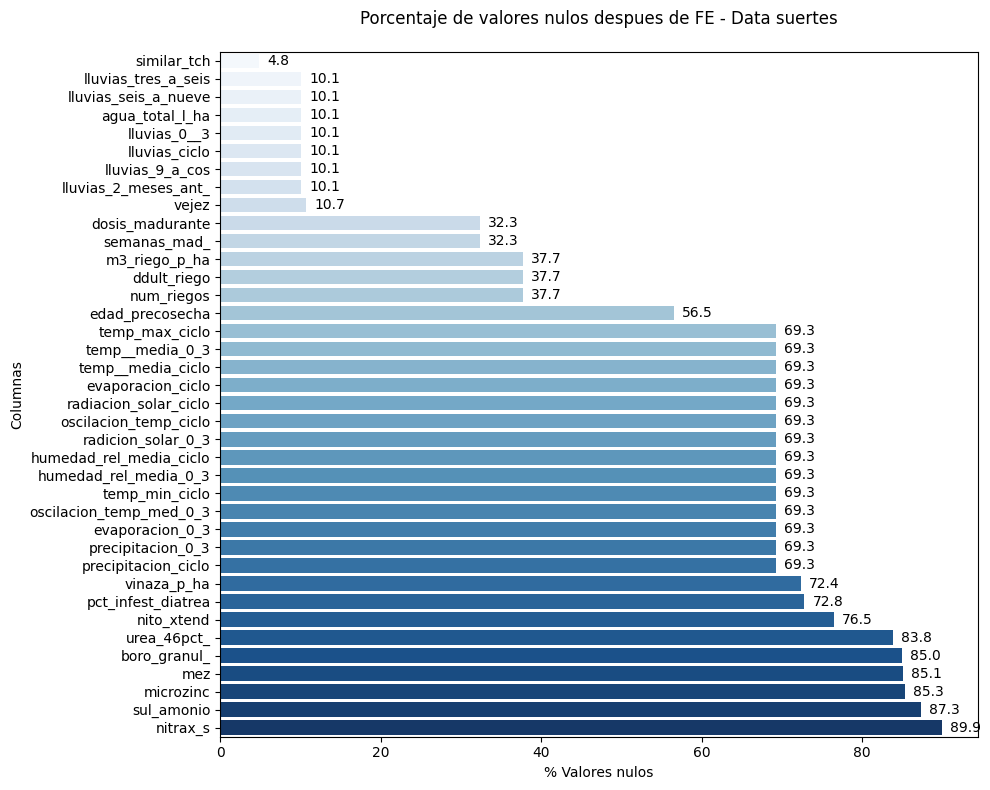

In [227]:
plt.figure(figsize=(10, 8))
temp_df = temp_df[temp_df["pct_nan"] > 1].reset_index()
ax = sns.barplot(x="pct_nan", y="index", data=temp_df, palette="Blues")

# Añadir los valores al final de cada barra
for p in ax.patches:
    width = p.get_width()  # Obtener el ancho de la barra (valor x)
    ax.text(
        width + 1,  # Posición x: ancho de la barra + pequeño margen
        p.get_y() + p.get_height() / 2,  # Posición y: centro de la barra
        f"{width:.1f}",  # Texto: valor formateado sin decimales
        ha="left",  # Alineación horizontal izquierda
        va="center",
    )  # Alineación vertical centrada

# Personalización adicional
plt.title("Porcentaje de valores nulos despues de FE - Data suertes", pad=20)
plt.xlabel("% Valores nulos")
plt.ylabel("Columnas")
# sns.despine()  # Remover bordes superfluos

plt.tight_layout()
plt.show()

In [228]:
# Export df to output DIR --- AWARE-ONLY WHEN NEEDED
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "suertes_for_reg.csv")
df.to_csv(OUTPUT_FILE)